In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Setup ready")

Setup ready


In [2]:
data_path = "../data/raw/Online Retail.xlsx"

df = pd.read_excel(data_path)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/Online Retail.xlsx'

In [3]:
import os

print("Current notebook folder:")
print(os.getcwd())

print("\nFiles in current folder:")
print(os.listdir())

Current notebook folder:
/Users/kasulajayaditya/Documents/MINI PROJECT

Files in current folder:
['app', 'models', '.venv', 'customer_segmentation.ipynb', 'data', 'outputs', 'notebooks', 'src']


In [4]:
print("Files inside data/raw:")

raw_path = "/Users/kasulajayaditya/Documents/MINI PROJECT/data/raw"
print(os.listdir(raw_path))


Files inside data/raw:
['Online Retail.xlsx']


In [5]:
data_path = "/Users/kasulajayaditya/Documents/MINI PROJECT/data/raw/Online Retail.xlsx"

df = pd.read_excel(data_path)

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.shape


(541909, 8)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 40.0+ MB


In [8]:
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
data = df.copy()

data = data.dropna(subset=["CustomerID"])

data = data[data["Quantity"] > 0]
data = data[data["UnitPrice"] > 0]

data["CustomerID"] = data["CustomerID"].astype(int)
data["InvoiceDate"] = pd.to_datetime(data["InvoiceDate"])

data["TotalAmount"] = data["Quantity"] * data["UnitPrice"]

data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [11]:
data.shape


(397884, 9)

In [12]:
data.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64

In [13]:
snapshot_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = data.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalAmount": "sum"
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [14]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2054.266460
std,1721.808492,100.014169,7.697998,8989.230441
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,307.415000
50%,15299.500000,51.000000,2.000000,674.485000
75%,16778.750000,142.000000,5.000000,1661.740000
max,18287.000000,374.000000,209.000000,280206.020000


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm[["Recency", "Frequency", "Monetary"]])

rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

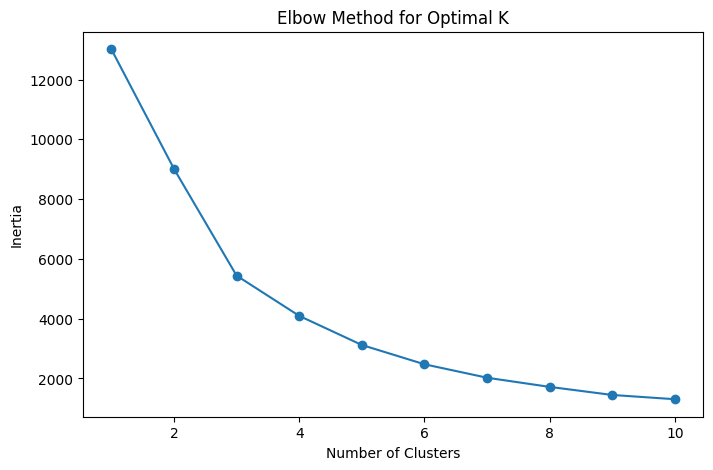

In [16]:
inertia = []

K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [17]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,0
2,12348,75,4,1797.24,0
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,1


In [18]:
rfm["Cluster"].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [19]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency": "mean",
    "Frequency": "mean",
    "Monetary": "mean",
    "CustomerID": "count"
}).reset_index()

cluster_summary.columns = [
    "Cluster",
    "Avg_Recency",
    "Avg_Frequency",
    "Avg_Monetary",
    "Customer_Count"
]

cluster_summary

,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Count
0,0,43.702685,3.682711,1359.049284,3054
1,1,248.075914,1.552015,480.617480,1067
2,2,7.384615,82.538462,127338.313846,13
3,3,15.500000,22.333333,12709.090490,204


In [20]:
cluster_summary.sort_values(by="Avg_Monetary", ascending=False)

,Cluster,Avg_Recency,Avg_Frequency,Avg_Monetary,Customer_Count
2,2,7.384615,82.538462,127338.313846,13
3,3,15.500000,22.333333,12709.090490,204
0,0,43.702685,3.682711,1359.049284,3054
1,1,248.075914,1.552015,480.617480,1067


In [21]:
def assign_segment(row):
    if row["Recency"] <= rfm["Recency"].quantile(0.33) and row["Frequency"] >= rfm["Frequency"].quantile(0.66) and row["Monetary"] >= rfm["Monetary"].quantile(0.66):
        return "Premium Customers"
    elif row["Recency"] <= rfm["Recency"].quantile(0.50) and row["Frequency"] >= rfm["Frequency"].quantile(0.50):
        return "Loyal Customers"
    elif row["Recency"] >= rfm["Recency"].quantile(0.66):
        return "At Risk Customers"
    else:
        return "New/Occasional Customers"

rfm["Segment"] = rfm.apply(assign_segment, axis=1)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,3,At Risk Customers
1,12347,2,7,4310.00,0,Premium Customers
2,12348,75,4,1797.24,0,New/Occasional Customers
3,12349,19,1,1757.55,0,New/Occasional Customers
4,12350,310,1,334.40,1,At Risk Customers


In [22]:
rfm["Segment"].value_counts()

Segment
At Risk Customers           1483
Loyal Customers             1076
New/Occasional Customers    1034
Premium Customers            745
Name: count, dtype: int64

In [23]:
def recommend_incentive(segment):
    if segment == "Premium Customers":
        return "Exclusive membership rewards, early access offers, premium coupons"
    elif segment == "Loyal Customers":
        return "Loyalty points, cashback offers, personalized discounts"
    elif segment == "At Risk Customers":
        return "Reactivation coupons, limited-time discounts, free shipping"
    else:
        return "Welcome offers, product recommendations, small discount coupons"

rfm["Recommended_Incentive"] = rfm["Segment"].apply(recommend_incentive)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment,Recommended_Incentive
0,12346,326,1,77183.60,3,At Risk Customers,"Reactivation coupons, limited-time discounts, ..."
1,12347,2,7,4310.00,0,Premium Customers,"Exclusive membership rewards, early access off..."
2,12348,75,4,1797.24,0,New/Occasional Customers,"Welcome offers, product recommendations, small..."
3,12349,19,1,1757.55,0,New/Occasional Customers,"Welcome offers, product recommendations, small..."
4,12350,310,1,334.40,1,At Risk Customers,"Reactivation coupons, limited-time discounts, ..."


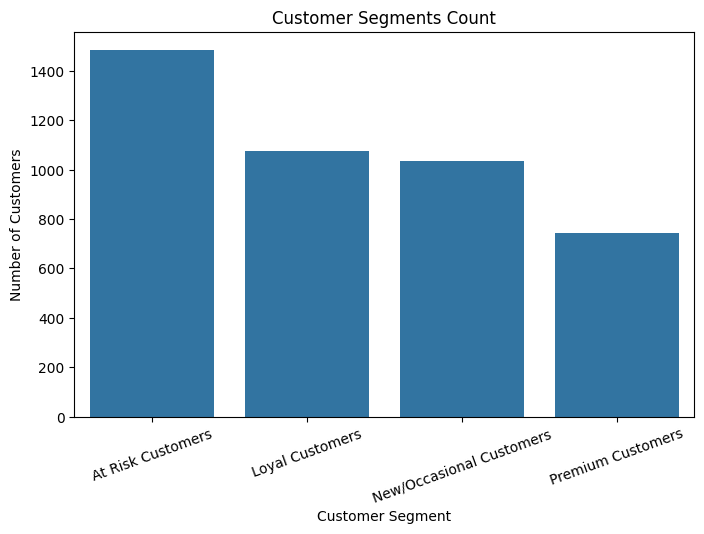

In [24]:
plt.figure(figsize=(8, 5))
sns.countplot(data=rfm, x="Segment", order=rfm["Segment"].value_counts().index)
plt.title("Customer Segments Count")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)
plt.show()

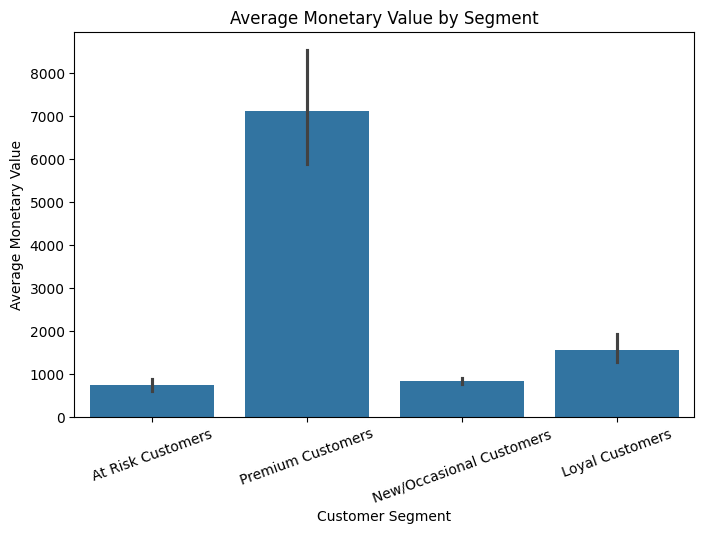

In [25]:
plt.figure(figsize=(8, 5))
sns.barplot(data=rfm, x="Segment", y="Monetary", estimator=np.mean)
plt.title("Average Monetary Value by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Monetary Value")
plt.xticks(rotation=20)
plt.show()

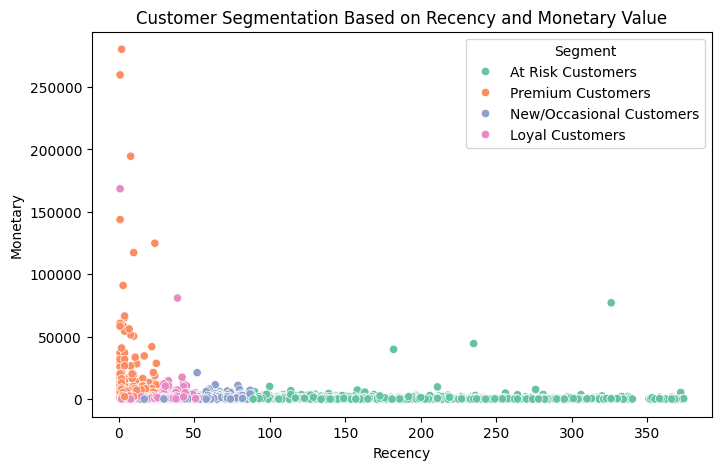

In [26]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Segment",
    palette="Set2"
)
plt.title("Customer Segmentation Based on Recency and Monetary Value")
plt.xlabel("Recency")
plt.ylabel("Monetary")
plt.show()

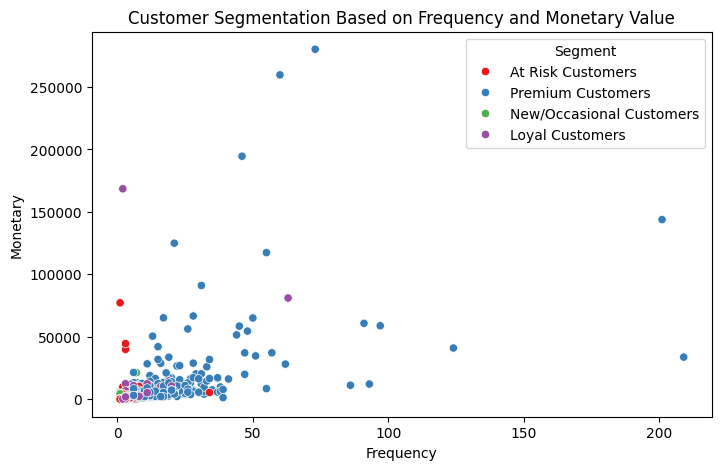

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    palette="Set1"
)
plt.title("Customer Segmentation Based on Frequency and Monetary Value")
plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.show()

In [28]:
output_path = "/Users/kasulajayaditya/Documents/MINI PROJECT/data/processed/customer_segments.csv"

rfm.to_csv(output_path, index=False)

print("Saved successfully:", output_path)

Saved successfully: /Users/kasulajayaditya/Documents/MINI PROJECT/data/processed/customer_segments.csv


In [29]:
import joblib

joblib.dump(kmeans, "/Users/kasulajayaditya/Documents/MINI PROJECT/models/kmeans_model.pkl")
joblib.dump(scaler, "/Users/kasulajayaditya/Documents/MINI PROJECT/models/scaler.pkl")

print("Model and scaler saved successfully")

Model and scaler saved successfully
